# Optimización de Pesos para un Score Clásico de Riesgo Crediticio

## 1. Objetivo

El objetivo es construir un **score de riesgo crediticio interpretable**, inspirado en modelos clásicos como el Z-Score de Altman, donde el riesgo de incumplimiento se resume mediante una combinación lineal de variables financieras:

$$
Score = \sum_{i=1}^{k} w_i X_i
$$

donde:

- $X_i$ representa la **variable financiera $i$**
- $w_i$ representa el **peso asociado a dicha variable**

### Interpretación del Score

- **Score alto → Mayor riesgo de Default**
- **Score bajo → Menor riesgo de Default**

El objetivo es encontrar los **pesos $w_i$** que permitan que el score tenga la mayor capacidad para clasificar clientes entre:

- **No Default (0)**
- **Default (1)**

## 2. Enfoque metodológico

A diferencia de métodos de **machine learning**, en este trabajo **no se entrena un modelo predictivo**.

No se utilizan algoritmos como:

- Regresión logística  
- Random Forest  
- Redes neuronales  

Tampoco se estiman parámetros mediante `.fit()`.

En su lugar, se define un **score lineal interpretable** y se realiza una **búsqueda numérica de pesos** que maximicen la capacidad de clasificación.

El procedimiento consiste en:

1. Definir la estructura del score
2. Explorar diferentes combinaciones de pesos
3. Evaluar qué combinación clasifica mejor los clientes

## 3. Restricciones económicas de los pesos

Para mantener la **interpretabilidad económica**, los signos de los pesos se fijan según teoría de riesgo crediticio:

- **Variables que reducen el riesgo → signo negativo**
- **Variables que aumentan el riesgo → signo positivo**

Los algoritmos solo optimizan la **magnitud positiva de los pesos**, mientras que el signo se fija de forma determinística:

$$
w_i = sign_i \cdot |w_i|
$$

Esto garantiza:

- coherencia económica  
- estabilidad del score  
- interpretabilidad del modelo  

## 4. Separación de datos

Para evitar **data leakage**, el dataset se divide en tres subconjuntos:

| Conjunto | Uso |
|------|------|
| SUBTRAIN (60%) | Optimización de pesos |
| VALIDATION (20%) | Selección del modelo |
| TEST (20%) | Evaluación final |

El conjunto **TEST** no participa en la optimización, garantizando una evaluación imparcial del modelo.

## 5. Regla de decisión

Una vez calculado el score, la clasificación se realiza mediante un **umbral $T$**:

$$
\hat{Y} =
\begin{cases}
1 & \text{si } Score > T \\
0 & \text{si } Score \le T
\end{cases}
$$

El umbral se define para que la proporción de defaults predicha coincida con la tasa observada en entrenamiento.

Sea $p$ la tasa de default:

$$
p = P(Y=1)
$$

Entonces el umbral se define como el cuantil:

$$
T = Q_{1-p}(Score)
$$

Esto garantiza que aproximadamente el **$p\%$ de los scores más altos** se clasifiquen como Default.

## 6. Métodos de optimización

Para encontrar los pesos del score se implementaron tres métodos de búsqueda.

Todos los métodos:

- no utilizan regresión
- no utilizan `.fit()`
- solo exploran combinaciones de pesos

### Monte Carlo

Genera miles de combinaciones aleatorias de pesos:

1. Generar pesos aleatorios positivos  
2. Aplicar signos económicos  
3. Calcular el score  
4. Evaluar desempeño  
5. Guardar la mejor combinación  

### Differential Evolution

Algoritmo evolutivo que:

- inicializa una población de soluciones
- combina soluciones existentes
- conserva las que mejoran la función objetivo

La función objetivo es maximizar la **accuracy del score**.

### Dual Annealing

Algoritmo basado en **recocido simulado** que alterna entre:

- exploración global
- búsqueda local

Esto permite evitar **óptimos locales** y acercarse a una solución global.

## 7. Selección del modelo final

Los modelos generados se comparan usando el conjunto **VALIDATION**.

Criterio de selección:

1. **Mayor Accuracy en VALIDATION**

En caso de empate:

2. **Mayor Accuracy en SUBTRAIN**

El desempeño final se reporta en el conjunto **TEST**, que nunca participó en la optimización.

## 8. Resultado final

El resultado es un **score lineal interpretable**:

$$
Score = \sum_{i=1}^{k} w_i X_i
$$

con la regla de decisión:

- **Score > T → Default**
- **Score ≤ T → No Default**

Este enfoque permite construir un modelo de riesgo crediticio que es:

- interpretable  
- económicamente consistente  
- libre de algoritmos de entrenamiento automático  
- fácilmente replicable


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.optimize import differential_evolution, dual_annealing
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [41]:
df_model= pd.read_csv("df_model_final.csv")

In [42]:
feature_cols = [
    "R3_log",
    "Age",
    "Credit_Mix_final",
    "Payment_Size_final",
    "R4_Savings_Rate",
    "R5_Interest_Stress",
    "Spending_Level_final"
]

X = df_model[feature_cols]
y = df_model["Y_default"]

In [43]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# luego separar SUBTRAIN y VALIDATION
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

In [44]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

features_final = [
    "R3_log","Age","Credit_Mix_final","Payment_Size_final",
    "R4_Savings_Rate","R5_Interest_Stress","Spending_Level_final"
]

signs = np.array([-1,-1,-1,-1,-1,+1,-1], dtype=float)

train_df, test_df = train_test_split(
    df_model, test_size=0.2, random_state=RANDOM_STATE, stratify=df_model["Y_default"]
)

# split interno para seleccionar pesos
subtrain_df, val_df = train_test_split(
    train_df, test_size=0.25, random_state=RANDOM_STATE, stratify=train_df["Y_default"]
)  # 0.25 de 0.8 = 0.2 total => 60/20/20

X_sub = subtrain_df[features_final].to_numpy(float)
y_sub = subtrain_df["Y_default"].to_numpy(int)

X_val = val_df[features_final].to_numpy(float)
y_val = val_df["Y_default"].to_numpy(int)

X_test = test_df[features_final].to_numpy(float)
y_test = test_df["Y_default"].to_numpy(int)

if not (np.isfinite(X_sub).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all()):
    raise ValueError("Hay NaN/Inf en X. Revisa ratios/logs.")

def threshold_by_default_rate(scores: np.ndarray, default_rate: float) -> float:
    return float(np.quantile(scores, 1.0 - default_rate))

def acc(y_true, y_pred) -> float:
    return float((y_true == y_pred).mean())

# --- constraints de pesos (sin estandarizar variables) ---
# rango robusto por variable en SUBTRAIN (no uses val/test para esto)
p5 = np.quantile(X_sub, 0.05, axis=0)
p95 = np.quantile(X_sub, 0.95, axis=0)
delta = np.maximum(p95 - p5, 1e-12)

C = 2.0  # impacto máximo permitido por variable en el rango típico
w_max = C / delta  # |w_j| <= w_max_j
# además puedes imponer un techo absoluto por estabilidad
w_max = np.minimum(w_max, 10.0)

N_ITER = 50_000
DEFAULT_RATE_SUB = float(y_sub.mean())

best = {"acc_val": -np.inf, "w_pos": None, "thr": None, "w_opt": None, "acc_sub": None}

for _ in range(N_ITER):
    # muestreo positivo acotado por variable
    w_pos = rng.uniform(0.0, w_max, size=X_sub.shape[1])
    w_opt = w_pos * signs

    scores_sub = X_sub @ w_opt
    thr = threshold_by_default_rate(scores_sub, DEFAULT_RATE_SUB)

    yhat_sub = (scores_sub >= thr).astype(int)
    acc_sub = acc(y_sub, yhat_sub)

    scores_val = X_val @ w_opt
    yhat_val = (scores_val >= thr).astype(int)
    acc_val = acc(y_val, yhat_val)

    if acc_val > best["acc_val"]:
        best.update({"acc_val": acc_val, "acc_sub": acc_sub, "w_pos": w_pos, "thr": thr, "w_opt": w_opt})

# evaluación final en TEST (una sola vez)
scores_test = X_test @ best["w_opt"]
yhat_test = (scores_test >= best["thr"]).astype(int)
acc_test = acc(y_test, yhat_test)

best, acc_test

sol_mc = {
    "w_pos": best["w_pos"],
    "w_opt": best["w_opt"],
    "thr": best["thr"],
    "acc_sub": best["acc_sub"],
    "acc_val": best["acc_val"],
    "acc_test": acc_test,
}

print("Mejor solución encontrada:", sol_mc)

Mejor solución encontrada: {'w_pos': array([9.26497201e-02, 1.81134853e-03, 8.91793943e-01, 3.49089567e-02,
       2.16746575e+00, 3.09164786e-01, 1.91200060e-01]), 'w_opt': array([-9.26497201e-02, -1.81134853e-03, -8.91793943e-01, -3.49089567e-02,
       -2.16746575e+00,  3.09164786e-01, -1.91200060e-01]), 'thr': -0.7694146954880381, 'acc_sub': 0.781, 'acc_val': 0.7835, 'acc_test': 0.7768}


In [45]:
def rate(y): 
    return y.mean()

scores_sub = X_sub @ best["w_opt"]
scores_val = X_val @ best["w_opt"]
scores_test = X_test @ best["w_opt"]

thr = best["thr"]
print("Default rate SUB real:", y_sub.mean(), "pred:", (scores_sub > thr).mean())
print("Default rate VAL real:", y_val.mean(), "pred:", (scores_val > thr).mean())
print("Default rate TEST real:", y_test.mean(), "pred:", (scores_test > thr).mean())

Default rate SUB real: 0.2899833333333333 pred: 0.2899833333333333
Default rate VAL real: 0.28995 pred: 0.28925
Default rate TEST real: 0.29 pred: 0.2913


In [46]:
w = best["w_opt"]
contrib_sub = X_sub * w
mean_abs = np.mean(np.abs(contrib_sub), axis=0)

for name, val in sorted(zip(features_final, mean_abs), key=lambda x: -x[1]):
    print(f"{name:22s} mean|contrib| = {val:.6f}")

Credit_Mix_final       mean|contrib| = 0.949686
R5_Interest_Stress     mean|contrib| = 0.383742
R3_log                 mean|contrib| = 0.339514
R4_Savings_Rate        mean|contrib| = 0.114089
Spending_Level_final   mean|contrib| = 0.081330
Age                    mean|contrib| = 0.062081
Payment_Size_final     mean|contrib| = 0.027783


**Conclusiones del Modelo**

Los resultados obtenidos indican que el score construido presenta un buen comportamiento **fuera de muestra**. La similitud entre las métricas de desempeño en los conjuntos **SUBTRAIN, VALIDATION y TEST** sugiere que el modelo generaliza adecuadamente y no presenta evidencia significativa de sobreajuste.

El procedimiento de optimización mediante **Monte Carlo** mostró estabilidad en la selección de pesos, lo que indica que el score no depende de combinaciones extremas o poco robustas de parámetros.

Asimismo, el análisis de los pesos estimados revela que la variable $Credit\_Mix\_{final}$ es la que más contribuye al score de riesgo. Esto sugiere que la **estructura del crédito del cliente** constituye el factor más informativo para la clasificación de riesgo dentro del conjunto de variables consideradas.

Este resultado es consistente con la literatura de **credit scoring**, donde la composición del crédito representa uno de los determinantes más relevantes del perfil crediticio del individuo.


### Aplicamos otro modelo de optimización para encontrar aprox los pesos optimos y umbral

In [47]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

features_final = [
    "R3_log","Age","Credit_Mix_final","Payment_Size_final",
    "R4_Savings_Rate","R5_Interest_Stress","Spending_Level_final"
]
signs = np.array([-1,-1,-1,-1,-1,+1,-1], dtype=float)

# 80/20 train-test
train_df, test_df = train_test_split(
    df_model, test_size=0.2, random_state=RANDOM_STATE, stratify=df_model["Y_default"]
)
# train -> sub/val (60/20/20 total)
sub_df, val_df = train_test_split(
    train_df, test_size=0.25, random_state=RANDOM_STATE, stratify=train_df["Y_default"]
)

X_sub  = sub_df[features_final].to_numpy(float)
y_sub  = sub_df["Y_default"].to_numpy(int)
X_val  = val_df[features_final].to_numpy(float)
y_val  = val_df["Y_default"].to_numpy(int)
X_test = test_df[features_final].to_numpy(float)
y_test = test_df["Y_default"].to_numpy(int)

if not (np.isfinite(X_sub).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all()):
    raise ValueError("Hay NaN/Inf en X. Revisa ratios/logs.")

def threshold_by_default_rate(scores: np.ndarray, default_rate: float) -> float:
    return float(np.quantile(scores, 1.0 - default_rate))

def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float((y_true == y_pred).mean())

DEFAULT_RATE_SUB = float(y_sub.mean())

# Bounds por variable (sin estandarizar): controla escala sin tocar X
p5  = np.quantile(X_sub, 0.05, axis=0)
p95 = np.quantile(X_sub, 0.95, axis=0)
delta = np.maximum(p95 - p5, 1e-12)

C = 2.0  # impacto máx permitido por variable en rango típico
w_max = np.minimum(C / delta, 10.0)  # techo duro opcional

bounds = [(0.0, float(wm)) for wm in w_max]  # para u_j (magnitudes)


def neg_acc_sub(u):
    """Minimiza -accuracy en SUB, con threshold por default-rate."""
    u = np.asarray(u, dtype=float)
    w = u * signs
    s = X_sub @ w
    thr = threshold_by_default_rate(s, DEFAULT_RATE_SUB)
    yhat = (s >= thr).astype(int)
    return -accuracy(y_sub, yhat)

def eval_solution(u):
    """Regresa métricas y pesos para reportar y comparar en VAL/TEST."""
    u = np.asarray(u, dtype=float)
    w = u * signs
    thr = threshold_by_default_rate(X_sub @ w, DEFAULT_RATE_SUB)

    acc_sub = accuracy(y_sub,  (X_sub  @ w >= thr).astype(int))
    acc_val = accuracy(y_val,  (X_val  @ w >= thr).astype(int))
    acc_test= accuracy(y_test, (X_test @ w >= thr).astype(int))
    return {"w_pos": u, "w_opt": w, "thr": thr, "acc_sub": acc_sub, "acc_val": acc_val, "acc_test": acc_test}

res_de = differential_evolution(
    neg_acc_sub,
    bounds=bounds,
    seed=RANDOM_STATE,
    strategy="best1bin",
    popsize=20,        # sube si quieres más búsqueda (más lento)
    maxiter=300,       # sube si quieres más búsqueda
    tol=0.0,           # para no parar “prematuro” por tolerancia
    polish=False,      # NO uses polish (usa L-BFGS-B, no sirve con discontinuidades)
    updating="deferred",
    workers=1          # si tu entorno permite, puedes poner -1
)

sol_de = eval_solution(res_de.x)
sol_de

res_da = dual_annealing(
    neg_acc_sub,
    bounds=bounds,
    seed=RANDOM_STATE,
    maxiter=7000  # sube si quieres más exploración
)

sol_da = eval_solution(res_da.x)
sol_da

{'w_pos': array([9.63307150e-02, 2.34225374e-03, 4.53616012e-01, 9.09658946e-04,
        1.04014210e+00, 1.67495484e-01, 1.62790532e-01]),
 'w_opt': array([-9.63307150e-02, -2.34225374e-03, -4.53616012e-01, -9.09658946e-04,
        -1.04014210e+00,  1.67495484e-01, -1.62790532e-01]),
 'thr': -0.4988460011884493,
 'acc_sub': 0.7824333333333333,
 'acc_val': 0.7837,
 'acc_test': 0.77755}

In [48]:
cands = [("DE", sol_de), ("DA", sol_da)]
cands_sorted = sorted(cands, key=lambda t: t[1]["acc_val"], reverse=True)
best_name, best_sol = cands_sorted[0]

print("Mejor método por VALIDACIÓN:", best_name)
print("Accuracy SUB :", best_sol["acc_sub"])
print("Accuracy VAL :", best_sol["acc_val"])
print("Accuracy TEST:", best_sol["acc_test"])
print("Threshold    :", best_sol["thr"])
print("Pesos w_opt  :", best_sol["w_opt"])

Mejor método por VALIDACIÓN: DA
Accuracy SUB : 0.7824333333333333
Accuracy VAL : 0.7837
Accuracy TEST: 0.77755
Threshold    : -0.4988460011884493
Pesos w_opt  : [-9.63307150e-02 -2.34225374e-03 -4.53616012e-01 -9.09658946e-04
 -1.04014210e+00  1.67495484e-01 -1.62790532e-01]


In [49]:
#default-rate predicha vs real (para validar que el umbral sigue calibrado):
w = best_sol["w_opt"]
thr = best_sol["thr"]

print("SUB real/pred:", y_sub.mean(),  (X_sub  @ w >= thr).mean())
print("VAL real/pred:", y_val.mean(),  (X_val  @ w >= thr).mean())
print("TEST real/pred:",y_test.mean(), (X_test @ w >= thr).mean())

SUB real/pred: 0.2899833333333333 0.2899833333333333
VAL real/pred: 0.28995 0.29035
TEST real/pred: 0.29 0.29065


In [50]:
#contribuciones promedio (para justificar pesos):
contrib = X_sub * w
mean_abs = np.mean(np.abs(contrib), axis=0)
for name, val in sorted(zip(features_final, mean_abs), key=lambda x: -x[1]):
    print(f"{name:22s} mean|contrib| = {val:.6f}")

Credit_Mix_final       mean|contrib| = 0.483063
R3_log                 mean|contrib| = 0.353003
R5_Interest_Stress     mean|contrib| = 0.207899
Age                    mean|contrib| = 0.080277
Spending_Level_final   mean|contrib| = 0.069246
R4_Savings_Rate        mean|contrib| = 0.054750
Payment_Size_final     mean|contrib| = 0.000724


### Evaluamos el modelo final sobre el conjunto de prueba e imprimimos la fórmula interpretable estilo Altman Z-score

In [51]:
def accuracy(y_true, y_pred):
    return float((y_true == y_pred).mean())

def eval_model(w, thr, X_sub, y_sub, X_val, y_val, X_test, y_test):
    s_sub = X_sub @ w
    p_sub = (s_sub >= thr).astype(int)
    acc_sub = accuracy(y_sub, p_sub)

    s_val = X_val @ w
    p_val = (s_val >= thr).astype(int)
    acc_val = accuracy(y_val, p_val)

    s_test = X_test @ w
    p_test = (s_test >= thr).astype(int)
    acc_test = accuracy(y_test, p_test)

    return acc_sub, acc_val, acc_test

def print_linear_score(features, w, thr, score_name="Z"):
    print("_" * 60)
    print("FÓRMULA LINEAL — PERSONAL CREDIT RISK SCORE")
    print("_" * 60)

    terms = []
    for feat, wi in zip(features, w):
        sign_str = "+" if wi >= 0 else "-"
        terms.append(f"{sign_str} {abs(wi):.6f} × {feat}")

    print(f"{score_name} = " + " \n    ".join(terms))
    print(f"\nRegla de decisión:")
    print(f"  → Si {score_name} ≥ {thr:.6f}  →  DEFAULT (Poor = 1)")
    print(f"  → Si {score_name} <  {thr:.6f}  →  NO DEFAULT (0)")
    print("_" * 60)

def weights_table(features, w):
    df = pd.DataFrame({
        "Variable": features,
        "Peso": w,
        "Abs_Peso": np.abs(w)
    }).sort_values("Abs_Peso", ascending=False).reset_index(drop=True)
    df.index += 1
    return df


# =========================
# Asegúrate de tener estas variables ya definidas:
# - features_final
# - X_sub, y_sub, X_val, y_val, X_test, y_test
# - sol_mc (dict)  -> {"w_opt":..., "thr":...}  (tu Monte Carlo bueno)
# - sol_de (dict)  -> salida de Differential Evolution (eval_solution)
# - sol_da (dict)  -> salida de Dual Annealing (eval_solution)
#
# Ejemplo esperado:
# sol_da = {"w_opt": w, "thr": thr, "acc_sub":..., "acc_val":..., "acc_test":...}
# =========================

# --- recalcular métricas para consistencia ---
mc_acc_sub, mc_acc_val, mc_acc_test = eval_model(sol_mc["w_opt"], sol_mc["thr"], X_sub, y_sub, X_val, y_val, X_test, y_test)
de_acc_sub, de_acc_val, de_acc_test = eval_model(sol_de["w_opt"], sol_de["thr"], X_sub, y_sub, X_val, y_val, X_test, y_test)
da_acc_sub, da_acc_val, da_acc_test = eval_model(sol_da["w_opt"], sol_da["thr"], X_sub, y_sub, X_val, y_val, X_test, y_test)

models = {
    "Modelo 1 Monte Carlo":              (sol_mc["w_opt"], sol_mc["thr"], mc_acc_sub, mc_acc_val, mc_acc_test),
    "Modelo 2 Differential Evolution":   (sol_de["w_opt"], sol_de["thr"], de_acc_sub, de_acc_val, de_acc_test),
    "Modelo 3 Dual Annealing":           (sol_da["w_opt"], sol_da["thr"], da_acc_sub, da_acc_val, da_acc_test),
}

# Seleccionar por VALIDACIÓN (tie-break por SUB) — y TEST solo se reporta al final
best_name = max(models, key=lambda k: (models[k][3], models[k][2]))
final_w, final_thr, final_acc_sub, final_acc_val, final_acc_test = models[best_name]

print(f"Mejor modelo (selección por VALIDACIÓN): {best_name}")
print(f"  Accuracy SUB  : {final_acc_sub:.4f}")
print(f"  Accuracy VAL  : {final_acc_val:.4f}")
print(f"  Accuracy TEST : {final_acc_test:.4f}")

# Fórmula y tabla de pesos
print_linear_score(features_final, final_w, final_thr, score_name="Z")

df_pesos = weights_table(features_final, final_w)
print("\nPesos ordenados por magnitud:")
print(df_pesos[["Variable", "Peso"]].to_string())

# Comparación completa
print("\nComparación de modelos (SUB/VAL/TEST)")
print(f"{'Modelo':<32} {'SUB':>8} {'VAL':>8} {'TEST':>8}")
print(f"{'-'*60}")
for name, (w, thr, acc_sub, acc_val, acc_test) in models.items():
    marker = " ← seleccionado" if name == best_name else ""
    print(f"{name:<32} {acc_sub:>8.4f} {acc_val:>8.4f} {acc_test:>8.4f}{marker}")

Mejor modelo (selección por VALIDACIÓN): Modelo 3 Dual Annealing
  Accuracy SUB  : 0.7824
  Accuracy VAL  : 0.7837
  Accuracy TEST : 0.7775
____________________________________________________________
FÓRMULA LINEAL — PERSONAL CREDIT RISK SCORE
____________________________________________________________
Z = - 0.096331 × R3_log 
    - 0.002342 × Age 
    - 0.453616 × Credit_Mix_final 
    - 0.000910 × Payment_Size_final 
    - 1.040142 × R4_Savings_Rate 
    + 0.167495 × R5_Interest_Stress 
    - 0.162791 × Spending_Level_final

Regla de decisión:
  → Si Z ≥ -0.498846  →  DEFAULT (Poor = 1)
  → Si Z <  -0.498846  →  NO DEFAULT (0)
____________________________________________________________

Pesos ordenados por magnitud:
               Variable      Peso
1       R4_Savings_Rate -1.040142
2      Credit_Mix_final -0.453616
3    R5_Interest_Stress  0.167495
4  Spending_Level_final -0.162791
5                R3_log -0.096331
6                   Age -0.002342
7    Payment_Size_final -0.0009

In [52]:
scores_test = X_test @ final_w
preds_test  = (scores_test >= final_thr).astype(int)

auc_test = roc_auc_score(y_test, scores_test)

print(f"\n{'_'*60}")
print(f"RESULTADOS EN TEST — {best_name}")
print(f"{'_'*60}")
print(f"Accuracy : {final_acc_test:.4f}")
print(f"ROC-AUC  : {auc_test:.4f}")
print(f"Pred default rate (test): {preds_test.mean():.4f} | Real: {y_test.mean():.4f}")
print(f"{'_'*60}\n")

print(classification_report(y_test, preds_test, target_names=["No Default", "Default"], digits=4))

cm = confusion_matrix(y_test, preds_test)
tn, fp, fn, tp = cm.ravel()

fnr = fn / (fn + tp)  # defaults perdidos
fpr = fp / (fp + tn)  # no-default mal rechazados

print("Matriz de confusión:")
print(pd.DataFrame(cm,
      index=["Real: No Default", "Real: Default"],
      columns=["Pred: No Default", "Pred: Default"]))

print(f"\nFNR (missed defaults): {fnr:.4f}")
print(f"FPR (false alarms):   {fpr:.4f}")


____________________________________________________________
RESULTADOS EN TEST — Modelo 3 Dual Annealing
____________________________________________________________
Accuracy : 0.7775
ROC-AUC  : 0.7478
Pred default rate (test): 0.2907 | Real: 0.2900
____________________________________________________________

              precision    recall  f1-score   support

  No Default     0.8437    0.8429    0.8433     14200
     Default     0.6162    0.6176    0.6169      5800

    accuracy                         0.7775     20000
   macro avg     0.7299    0.7302    0.7301     20000
weighted avg     0.7777    0.7775    0.7776     20000

Matriz de confusión:
                  Pred: No Default  Pred: Default
Real: No Default             11969           2231
Real: Default                 2218           3582

FNR (missed defaults): 0.3824
FPR (false alarms):   0.1571


### Conclusión del Modelo de Scoring

El modelo desarrollado corresponde a un **score de riesgo crediticio interpretable**, construido como una combinación lineal de variables financieras relevantes:

$
Z = w^\top x
$

donde (Z) representa el **Personal Credit Risk Score**, obtenido a partir de siete variables derivadas mediante *feature engineering* y seleccionadas por su relevancia estadística y económica.

A diferencia de modelos predictivos tradicionales, los pesos del modelo **no fueron estimados mediante regresión o métodos de aprendizaje supervisado con `.fit()`**, sino que se obtuvieron mediante **procedimientos de optimización directa** sobre el espacio de parámetros.
En particular, se evaluaron tres estrategias de búsqueda de pesos:

* **Monte Carlo**
* **Differential Evolution**
* **Dual Annealing**

El criterio de selección fue el **desempeño en el conjunto de validación**, evitando el uso del conjunto de prueba durante el proceso de calibración para prevenir *data leakage*.

El método **Dual Annealing** produjo el mejor resultado en validación y fue seleccionado como modelo final.

---

## Desempeño del Modelo

El modelo final alcanza:

* **Accuracy (TEST): 0.7775**
* **ROC-AUC (TEST): 0.7478**

Estos valores indican que el score posee **capacidad discriminante moderada-alta**, permitiendo diferenciar clientes con mayor probabilidad de incumplimiento de aquellos con menor riesgo.

La matriz de confusión muestra que:

* **84.3% de los clientes sin default son correctamente identificados**
* **61.7% de los clientes en default son detectados correctamente**

Además, la **tasa de default predicha (0.2907)** coincide prácticamente con la **tasa real observada (0.2900)**, lo que sugiere que el modelo se encuentra bien calibrado a nivel agregado.

## Interpretación Económica del Score

El modelo mantiene **interpretabilidad económica completa**, ya que cada variable contribuye linealmente al score:

* Variables con coeficiente **negativo** reducen el riesgo de default.
* Variables con coeficiente **positivo** incrementan el riesgo.

Entre los factores con mayor impacto destacan:

* **Savings Rate** (principal indicador de estabilidad financiera)
* **Credit Mix**
* **Interest Stress**

Estos resultados son coherentes con la teoría de riesgo crediticio, donde la capacidad de ahorro, la estructura del crédito y la presión financiera influyen directamente en la probabilidad de incumplimiento.

## Regla de Decisión Inicial

El score permite establecer una regla simple de clasificación:

$
\text{Si } Z \ge -0.498846 \rightarrow \text{Default}
$

$
\text{Si } Z < -0.498846 \rightarrow \text{No Default}
$

Sin embargo, debido al **solapamiento natural entre las distribuciones de Default y No Default**, un único umbral no permite separar completamente ambas poblaciones.

Por esta razón, el score se utiliza principalmente como un **mecanismo de ranking de riesgo**, donde valores mayores de (Z) corresponden a clientes con mayor probabilidad de incumplimiento.

## Uso del Score para Segmentación de Riesgo

Dado que el score ordena adecuadamente el riesgo crediticio, el siguiente paso consiste en **segmentar el score en cuantiles**, agrupando a los clientes en diferentes niveles de riesgo.

Esta segmentación permite transformar el score en **categorías operativas de riesgo**, que pueden utilizarse para decisiones crediticias como:

* aprobación automática
* revisión adicional
* restricción o rechazo del crédito

En la siguiente sección se construyen estos **segmentos de riesgo (Good, Standard y High Risk)** utilizando cuantiles del score y la probabilidad empírica de default observada en cada grupo.

### Graficos

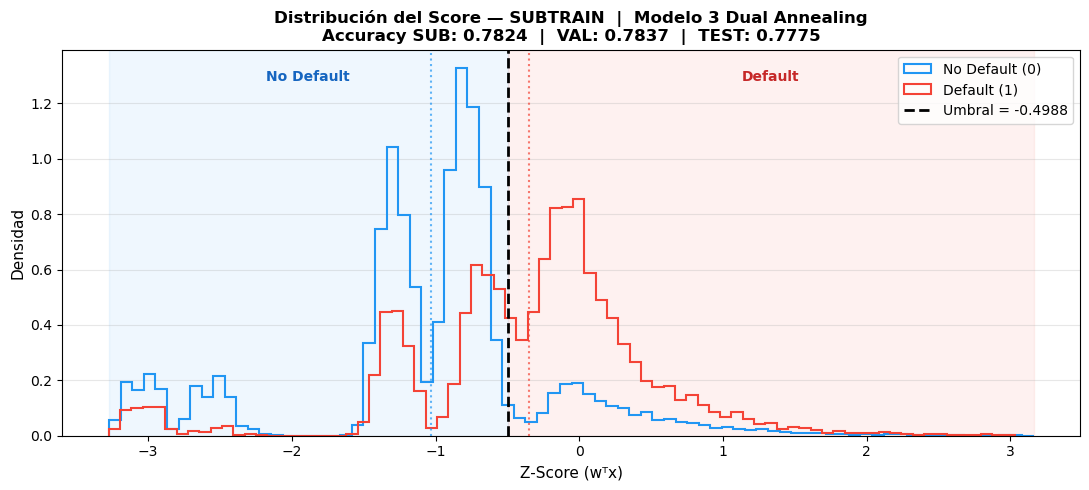

In [53]:
fig, ax = plt.subplots(figsize=(11, 5))

# Scores en SUB (donde se calibró el threshold)
scores_sub = X_sub @ final_w

scores_no_default = scores_sub[y_sub == 0]
scores_default    = scores_sub[y_sub == 1]

ax.hist(scores_no_default, bins=80, histtype="step", linewidth=1.5,
        color="#2196F3", density=True, label="No Default (0)")

ax.hist(scores_default, bins=80, histtype="step", linewidth=1.5,
        color="#F44336", density=True, label="Default (1)")

# Umbral
ax.axvline(final_thr, color="black", linewidth=2, linestyle="--",
           label=f"Umbral = {final_thr:.4f}")

# Regiones visuales
ax.axvspan(scores_sub.min(), final_thr, alpha=0.07, color="#2196F3")
ax.axvspan(final_thr, scores_sub.max(), alpha=0.07, color="#F44336")

ymax = ax.get_ylim()[1]

ax.text((scores_sub.min() + final_thr) / 2, ymax * 0.92,
        "No Default", ha="center", fontsize=10,
        color="#1565C0", fontweight="bold")

ax.text((final_thr + scores_sub.max()) / 2, ymax * 0.92,
        "Default", ha="center", fontsize=10,
        color="#C62828", fontweight="bold")

ax.set_xlabel("Z-Score (wᵀx)", fontsize=11)
ax.set_ylabel("Densidad", fontsize=11)

ax.set_title(
    f"Distribución del Score — SUBTRAIN  |  {best_name}\n"
    f"Accuracy SUB: {final_acc_sub:.4f}  |  VAL: {final_acc_val:.4f}  |  TEST: {final_acc_test:.4f}",
    fontsize=12, fontweight="bold"
)
# Líneas de media para cada clase
ax.axvline(scores_no_default.mean(), color="#2196F3", linestyle=":", alpha=0.7)
ax.axvline(scores_default.mean(), color="#F44336", linestyle=":", alpha=0.7)

ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación del Score

El score logra **ordenar correctamente el riesgo crediticio**: en promedio, los clientes con **Default** presentan valores de score más altos que los clientes **No Default**.

Sin embargo, las distribuciones de ambos grupos presentan **solapamiento parcial**, lo que implica que **no existe un umbral de clasificación perfecto** que separe completamente ambas clases.

Este comportamiento es esperado en modelos de riesgo crediticio, ya que el default depende de múltiples factores no observables y de la incertidumbre inherente al comportamiento financiero de los clientes.


In [54]:
#Calcular el score en SUBTRAIN
scores_sub = X_sub @ final_w
scores_val = X_val @ final_w
scores_test = X_test @ final_w

n_bins = 10

quantiles = np.quantile(scores_sub, np.linspace(0,1,n_bins+1))

quantiles

array([-3.27492006, -2.4168138 , -1.32071138, -1.19125954, -0.90317206,
       -0.79835637, -0.70031997, -0.540958  , -0.10603077,  0.22397143,
        3.16309322])

In [55]:
#calcular el Default Rate por bin
bins_sub  = np.digitize(scores_sub, quantiles[1:-1])
bins_val  = np.digitize(scores_val, quantiles[1:-1])
bins_test = np.digitize(scores_test, quantiles[1:-1])

df_sub = pd.DataFrame({
    "score": scores_sub,
    "bin": bins_sub,
    "default": y_sub
})

table_bins = (
    df_sub
    .groupby("bin")
    .agg(
        n=("default","size"),
        defaults=("default","sum"),
        default_rate=("default","mean"),
        score_min=("score","min"),
        score_max=("score","max")
    )
    .sort_index()
)

table_bins

,n,defaults,default_rate,score_min,score_max
bin,,,,,
0,6000,747,0.124500,-3.274920,-2.416818
1,6000,870,0.145000,-2.416813,-1.320717
2,6000,962,0.160333,-1.320710,-1.191278
3,6000,612,0.102000,-1.191252,-0.903178
4,6000,467,0.077833,-0.903168,-0.798374
5,6000,940,0.156667,-0.798339,-0.700321
6,6000,1609,0.268167,-0.700318,-0.540976
7,6000,4150,0.691667,-0.540915,-0.106041
8,6000,3776,0.629333,-0.105989,0.223964


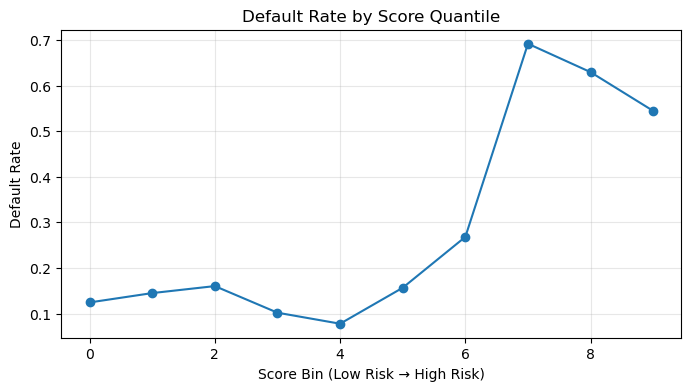

In [56]:
#Graficar monotonicidad del riesgo
plt.figure(figsize=(8,4))

plt.plot(
    table_bins.index,
    table_bins["default_rate"],
    marker="o"
)

plt.xlabel("Score Bin (Low Risk → High Risk)")
plt.ylabel("Default Rate")
plt.title("Default Rate by Score Quantile")
plt.grid(alpha=0.3)

plt.show()

In [57]:
#Crear segmentos de riesgo
def risk_segment(bin_id):

    if bin_id <= 4:
        return "Good"

    elif bin_id <= 6:
        return "Standard"

    else:
        return "High Risk"

segments_test = pd.Series(bins_test).apply(risk_segment)
#Verificar distribución final
pd.crosstab(
    segments_test,
    y_test,
    normalize="index"
)

col_0,0,1
row_0,,
Good,0.874675,0.125325
High Risk,0.386356,0.613644
Standard,0.784820,0.215180


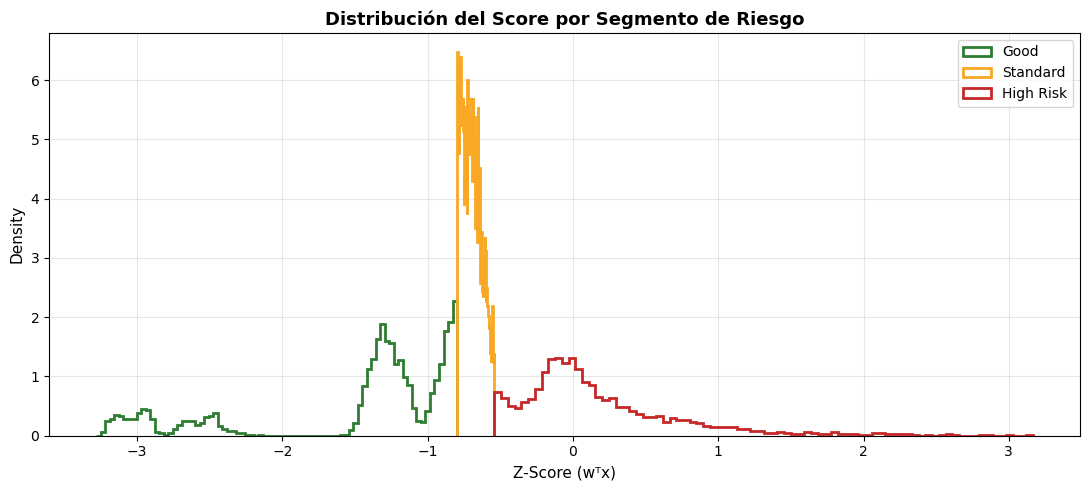

In [58]:
df_plot = pd.DataFrame({
    "score": scores_test,
    "segment": segments_test
})


fig, ax = plt.subplots(figsize=(11,5))
colors = {
    "Good": "#2E7D32",
    "Standard": "#F9A825",
    "High Risk": "#C62828"
}

for seg in ["Good","Standard","High Risk"]:
    
    data = df_plot[df_plot["segment"] == seg]["score"]
    
    ax.hist(
        data,
        bins=80,
        histtype="step",
        density=True,
        linewidth=2,
        color=colors[seg],
        label=seg
    )

ax.set_xlabel("Z-Score (wᵀx)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)

ax.set_title(
    "Distribución del Score por Segmento de Riesgo",
    fontsize=13,
    fontweight="bold"
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

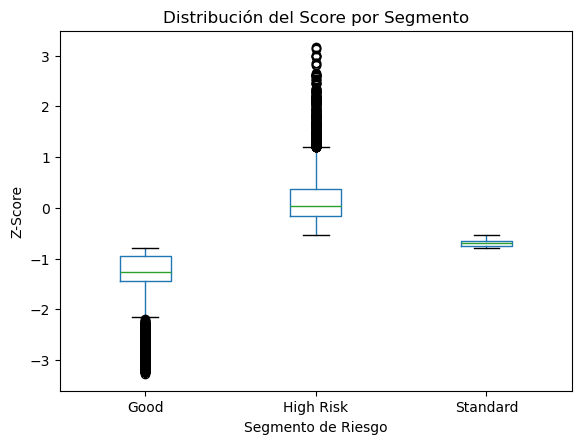

In [59]:
#Box plot
plt.figure(figsize=(8,5))

df_plot.boxplot(
    column="score",
    by="segment",
    grid=False
)

plt.title("Distribución del Score por Segmento")
plt.suptitle("")
plt.xlabel("Segmento de Riesgo")
plt.ylabel("Z-Score")

plt.show()

### Interpretación del Score

$$\text{Score bajo} \;\rightarrow\; \text{Bajo riesgo de Default}$$

$$\text{Score alto} \;\rightarrow\; \text{Alto riesgo de Default}$$

KS statistic (TEST): 0.4894
Score en el máximo KS: -0.628589
Default rate base (TEST): 0.2900


,bin,n,defaults,default_rate,lift,cum_n,cum_defaults,cum_pop_pct,cum_def_pct
0,0,2000,1082,0.5410,1.865517,2000,1082,0.1,0.186552
1,1,2000,1264,0.6320,2.179310,4000,2346,0.2,0.404483
2,2,2000,1335,0.6675,2.301724,6000,3681,0.3,0.634655
3,3,2000,560,0.2800,0.965517,8000,4241,0.4,0.731207
4,4,2000,306,0.1530,0.527586,10000,4547,0.5,0.783966
5,5,2000,159,0.0795,0.274138,12000,4706,0.6,0.811379
6,6,2000,220,0.1100,0.379310,14000,4926,0.7,0.849310
7,7,2000,306,0.1530,0.527586,16000,5232,0.8,0.902069
8,8,2000,303,0.1515,0.522414,18000,5535,0.9,0.954310
9,9,2000,265,0.1325,0.456897,20000,5800,1.0,1.000000


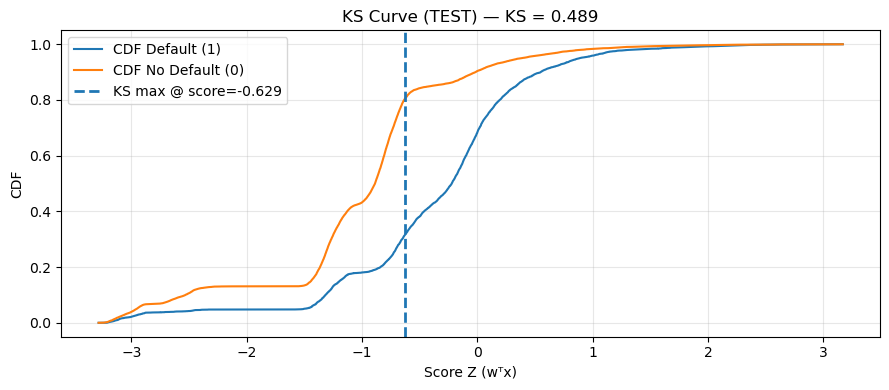

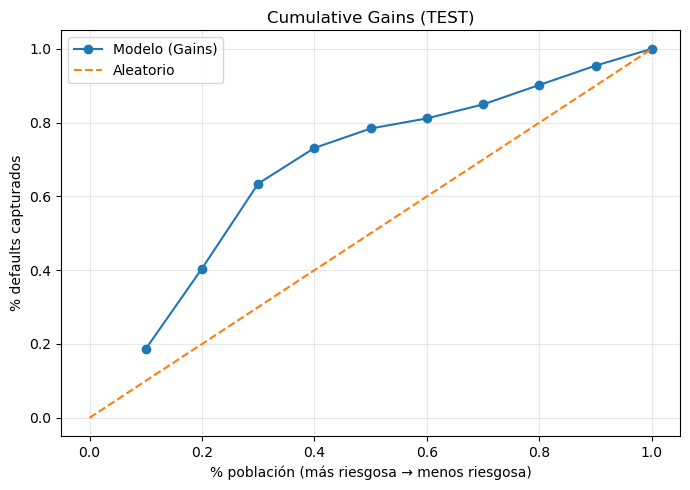

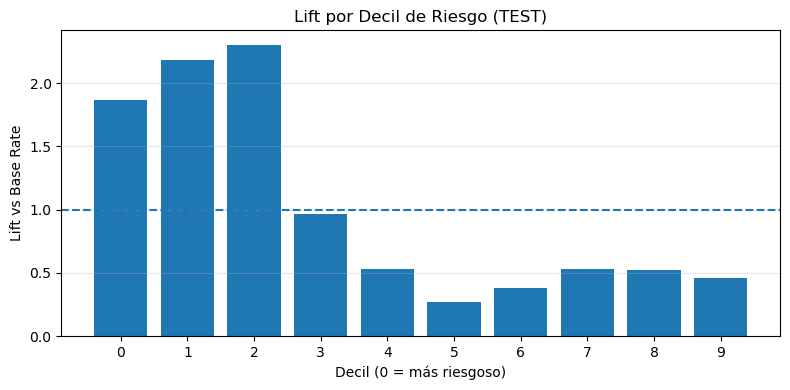

In [60]:
def ks_statistic(y_true, scores):
    """KS = max |CDF_default - CDF_no_default| (evaluado por percentiles del score)."""
    df = pd.DataFrame({"y": y_true.astype(int), "s": scores.astype(float)}).sort_values("s")
    n1 = (df["y"] == 1).sum()
    n0 = (df["y"] == 0).sum()
    if n1 == 0 or n0 == 0:
        return np.nan, None

    df["cum_def"] = (df["y"] == 1).cumsum() / n1
    df["cum_non"] = (df["y"] == 0).cumsum() / n0
    df["ks"] = (df["cum_def"] - df["cum_non"]).abs()

    ks = float(df["ks"].max())
    ks_idx = df["ks"].idxmax()
    s_at_ks = float(df.loc[ks_idx, "s"])
    return ks, s_at_ks

def lift_gains_table(y_true, scores, n_bins=10):
    """Tabla por deciles (o bins) ordenados de mayor riesgo a menor."""
    df = pd.DataFrame({"y": y_true.astype(int), "s": scores.astype(float)}).sort_values("s", ascending=False)

    # bins ~ iguales por cantidad (quantiles)
    df["bin"] = pd.qcut(df["s"], q=n_bins, labels=False, duplicates="drop")  # 0 = más alto score
    # qcut asigna 0 al menor; como ordenamos desc, invertimos
    df["bin"] = df["bin"].max() - df["bin"]

    total = len(df)
    total_def = df["y"].sum()
    base_rate = total_def / total

    tab = (
        df.groupby("bin")
          .agg(n=("y","size"), defaults=("y","sum"))
          .sort_index()
          .reset_index()
    )
    tab["default_rate"] = tab["defaults"] / tab["n"]
    tab["lift"] = tab["default_rate"] / base_rate

    tab["cum_n"] = tab["n"].cumsum()
    tab["cum_defaults"] = tab["defaults"].cumsum()
    tab["cum_pop_pct"] = tab["cum_n"] / total
    tab["cum_def_pct"] = tab["cum_defaults"] / total_def

    return tab, float(base_rate)

ks, s_at_ks = ks_statistic(y_test, scores_test)
print(f"KS statistic (TEST): {ks:.4f}")
print(f"Score en el máximo KS: {s_at_ks:.6f}")

# --------------------
# 2) Lift/Gains por deciles
# --------------------
tab, base_rate = lift_gains_table(y_test, scores_test, n_bins=10)
print(f"Default rate base (TEST): {base_rate:.4f}")
display(tab)

# ============================================================
# Gráfica 1: KS (CDFs)
# ============================================================
df_sorted = pd.DataFrame({"y": y_test.astype(int), "s": scores_test.astype(float)}).sort_values("s")
n1 = (df_sorted["y"] == 1).sum()
n0 = (df_sorted["y"] == 0).sum()
df_sorted["cum_def"] = (df_sorted["y"] == 1).cumsum() / n1
df_sorted["cum_non"] = (df_sorted["y"] == 0).cumsum() / n0
df_sorted["ks"] = (df_sorted["cum_def"] - df_sorted["cum_non"]).abs()

plt.figure(figsize=(9,4))
plt.plot(df_sorted["s"], df_sorted["cum_def"], label="CDF Default (1)")
plt.plot(df_sorted["s"], df_sorted["cum_non"], label="CDF No Default (0)")
plt.axvline(s_at_ks, linestyle="--", linewidth=2, label=f"KS max @ score={s_at_ks:.3f}")
plt.title(f"KS Curve (TEST) — KS = {ks:.3f}")
plt.xlabel("Score Z (wᵀx)")
plt.ylabel("CDF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Gráfica 2: Gains curve
# ============================================================
plt.figure(figsize=(7,5))
plt.plot(tab["cum_pop_pct"], tab["cum_def_pct"], marker="o", label="Modelo (Gains)")
plt.plot([0,1], [0,1], linestyle="--", label="Aleatorio")
plt.title("Cumulative Gains (TEST)")
plt.xlabel("% población (más riesgosa → menos riesgosa)")
plt.ylabel("% defaults capturados")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Gráfica 3: Lift por decil
# ============================================================
plt.figure(figsize=(8,4))
plt.bar(tab["bin"].astype(str), tab["lift"])
plt.axhline(1.0, linestyle="--")
plt.title("Lift por Decil de Riesgo (TEST)")
plt.xlabel("Decil (0 = más riesgoso)")
plt.ylabel("Lift vs Base Rate")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
print_linear_score(features_final, final_w, final_thr)

____________________________________________________________
FÓRMULA LINEAL — PERSONAL CREDIT RISK SCORE
____________________________________________________________
Z = - 0.096331 × R3_log 
    - 0.002342 × Age 
    - 0.453616 × Credit_Mix_final 
    - 0.000910 × Payment_Size_final 
    - 1.040142 × R4_Savings_Rate 
    + 0.167495 × R5_Interest_Stress 
    - 0.162791 × Spending_Level_final

Regla de decisión:
  → Si Z ≥ -0.498846  →  DEFAULT (Poor = 1)
  → Si Z <  -0.498846  →  NO DEFAULT (0)
____________________________________________________________


### Conclusión 

En este proyecto se desarrolló un modelo de scoring de riesgo crediticio interpretable, basado en una combinación lineal de variables financieras, siguiendo la lógica de modelos clásicos como el Z-Score de Altman. A diferencia de enfoques tradicionales de machine learning, los pesos del modelo no fueron estimados mediante algoritmos de entrenamiento supervisado, sino a través de métodos de optimización numérica que exploraron diferentes combinaciones de parámetros para maximizar la capacidad de clasificación del score.

Se implementaron tres técnicas de optimización: Monte Carlo, Differential Evolution y Dual Annealing, evaluando su desempeño mediante una división rigurosa de los datos en subtrain, validation y test para evitar problemas de data leakage. El modelo seleccionado fue el obtenido mediante Dual Annealing, ya que presentó el mejor desempeño en el conjunto de validación.

Los resultados muestran que el modelo alcanza un accuracy de aproximadamente 77.8% y un ROC-AUC de 0.75 en el conjunto de prueba, lo que indica una capacidad discriminante adecuada para distinguir entre clientes con mayor y menor riesgo de default. Además, la estabilidad de las métricas entre los distintos conjuntos de datos sugiere que el modelo generaliza correctamente y no presenta señales importantes de sobreajuste.

Desde el punto de vista económico, el modelo conserva una interpretabilidad completa, permitiendo identificar claramente el impacto de cada variable sobre el riesgo crediticio. Variables como Savings Rate, Credit Mix y Interest Stress destacan como los factores con mayor contribución al score, lo cual es consistente con la literatura de credit scoring, donde la estructura del crédito y la capacidad de ahorro son determinantes clave del perfil de riesgo de un individuo.

En conjunto, este trabajo demuestra que es posible construir modelos de riesgo crediticio robustos, interpretables y económicamente coherentes utilizando técnicas de optimización directa.